Installations

In [1]:
import pandas as pd
import pytz
import re
import unicodedata
import nltk
import json
nltk.download('punkt')
nltk.download('punkt_tab')
from nltk.tokenize import word_tokenize
nltk.download('stopwords')
from nltk.corpus import stopwords
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from scipy.sparse import csr_matrix

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\fatim\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\fatim\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\fatim\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


commnets

In [2]:
comments = pd.read_csv('test_dummy_comments_2.csv')
data = comments.loc[:,['comments']]
data

,comments
0,Air mati sejak pagi.
1,Air tidak mengalir hari ini.
2,Keran tidak keluar air.
3,Air mati lagi.
4,Sudah lama air tidak nyala.
5,Air mati tanpa info.
6,Air tidak ada dari tadi.
7,Air mati semalaman.
8,Air belum hidup.
9,Air mati terus.


Drop empty comments
Remove comments from pdamsuryasembada
Change date from epoch miliseconds
Remove taggings from comments

In [3]:
# data = data[data['username'].str.contains('pdamsuryasembada') == False]

data = data.drop_duplicates(subset=['comments'])

# local_timezone = pytz.timezone('Asia/Jakarta')
# data['created_at'] = pd.to_datetime(data['created_at'], unit='s')
# data['created_at'] = data['created_at'].dt.tz_localize('UTC').dt.tz_convert(local_timezone)
# data['created_at'] = data['created_at'].dt.strftime('%Y-%m-%d %H:%M:%S %Z')

def remove_tags(text):
    if not isinstance(text, str):
        return ""
    return re.sub(r'@\w[\w\.]*', '', text).strip()

data['comments'] = data['comments'].apply(remove_tags)

data = data.dropna(subset=["comments"])
data = data[data["comments"].astype(str).str.strip() != ""]

cleaning

In [4]:
PUNCT_TO_REMOVE = "!#$%&()*+,./:;<=>@[\\]^_{|}~`"
def remove_punctuation(text):
    """custom function to remove the punctuation"""
    return text.translate(str.maketrans('', '', PUNCT_TO_REMOVE))

data["comments"] = data["comments"].apply(lambda text: remove_punctuation(text))

def remove_emojis(text):
    """Removes standard unicode emojis from the text."""
    if not isinstance(text, str):
        return text

    emoji_pattern = re.compile(
        "["                     
        u"\U0001F600-\U0001F64F"
        u"\U0001F300-\U0001F5FF"
        u"\U0001F680-\U0001F6FF"
        u"\U0001F1E0-\U0001F1FF"
        u"\U0001F700-\U0001F77F"
        u"\U0001F780-\U0001F7FF"
        u"\U0001F800-\U0001F8FF"
        u"\U0001F900-\U0001F9FF"
        u"\U0001FA70-\U0001FAFF"
        u"\u2600-\u26FF"
        u"\u2700-\u27BF"
        u"\ufe0f"
        "]+",
        flags=re.UNICODE,
    )

    return emoji_pattern.sub(r'', text)

data['comments'] = data['comments'].apply(remove_emojis)
data['comments'] = data['comments'].str.strip()

def normalize_fancy_unicode(text):
    if not isinstance(text, str):
        return text

    normalized = unicodedata.normalize("NFKD", text)

    cleaned = "".join(
        ch for ch in normalized
        if not unicodedata.combining(ch)
    )
    return cleaned

data["comments"] = data["comments"].apply(normalize_fancy_unicode)

data = data.dropna(subset=["comments"])
data = data[data["comments"].astype(str).str.strip() != ""]

case folding

In [5]:
data["comments"] = data["comments"].str.lower()

tokem

In [6]:
data['comments'] = data['comments'].astype(str).apply(word_tokenize)

In [7]:
def is_all_numbers(tokens):
    return all(re.fullmatch(r'\d+', tok) for tok in tokens)

data = data[~data['comments'].apply(is_all_numbers)]


def normalize_mixed_number_token(token):
    if re.fullmatch(r'\d+', token):
        return "<num>"
    
    parts = re.findall(r'\d+|[a-zA-Z]+', token)

    if len(parts) == 1:
        return token

    parts = ["<num>" if p.isdigit() else p for p in parts]

    return " ".join(parts)


def normalize_tokens(token_list):
    normalized = []
    for tok in token_list:
        if tok.isdigit():
            normalized.append("<num>")
        elif re.search(r'\d', tok):
            normalized.append(normalize_mixed_number_token(tok))
        else:
            normalized.append(tok)
    return normalized

data["comments"] = data["comments"].apply(normalize_tokens)

In [8]:
data_partial = data.copy()
# data_partial.to_csv('all_tokenized_v3.csv', index=False)
data_partial


,comments
0,"[air, mati, sejak, pagi]"
1,"[air, tidak, mengalir, hari, ini]"
2,"[keran, tidak, keluar, air]"
3,"[air, mati, lagi]"
4,"[sudah, lama, air, tidak, nyala]"
5,"[air, mati, tanpa, info]"
6,"[air, tidak, ada, dari, tadi]"
7,"[air, mati, semalaman]"
8,"[air, belum, hidup]"
9,"[air, mati, terus]"


formalize

In [9]:
with open("dictionary/dict_template3_doneig.json", "r", encoding="utf-8") as f:
    formal_dict3 = json.load(f)

with open("dictionary/dict4.json", "r", encoding="utf-8") as f:
    formal_dict4 = json.load(f)

formal_dict = {**formal_dict3, **formal_dict4}

def apply_formalization(tokens, formal_dict):
    
    new_tokens = []
    for tok in tokens:
        if tok in formal_dict:
            replacement = formal_dict[tok]
            new_tokens.extend(replacement.split())
            # new_tokens.append(formal_dict[tok]) 
        else:
            new_tokens.append(tok)
    return new_tokens

data_partial["comments"] = data_partial["comments"].apply(lambda tokens: apply_formalization(tokens, formal_dict))

delete stopwor

In [10]:
with open('stopwords_v3.txt', 'r', encoding='utf-8') as f:
    custom_stopwords = set([line.strip() for line in f if line.strip()])

def remove_stopwords(tokens, stopword_set):
    return [tok for tok in tokens if tok not in stopword_set and tok.strip() != ""]

data_partial["comments"] = data_partial["comments"].apply(lambda tokens: remove_stopwords(tokens, custom_stopwords))

stemmming

In [11]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.Stemmer.Stemmer import Stemmer
from Sastrawi.Stemmer.CachedStemmer import CachedStemmer
from Sastrawi.Stemmer.Cache.ArrayCache import ArrayCache
from Sastrawi.Dictionary.ArrayDictionary import ArrayDictionary

PROTECTED_WORDS = [
    'sememi',
]

factory = StemmerFactory()
base_words = factory.get_words_from_file()
combined_words = list(set(base_words + PROTECTED_WORDS))
custom_dict = ArrayDictionary(combined_words)
stemmer = CachedStemmer(ArrayCache(), Stemmer(custom_dict))

def stem_tokens(tokens):
    if not isinstance(tokens, list):
        return tokens
    return [stemmer.stem(tok) for tok in tokens]

data_partial["comments"] = data_partial["comments"].apply(stem_tokens)

In [12]:
# comments = pd.read_csv('stemmed_all_v5.csv')
# data_partial = comments.loc[:,['post_id','created_at','username','text']]
# data_partial = data_partial[(data_partial['created_at'] > '2025-10-01') & (data_partial['created_at'] < '2025-11-01')]
# import ast

# data_partial['text'] = data_partial['text'].apply(ast.literal_eval)
# data_partial
# data_partial.to_csv("stemmed_oct2025.csv", index=False)

tf(no IDF ig)

In [13]:

from sklearn.feature_extraction.text import TfidfVectorizer
data_partial['processed_text'] = data_partial['comments'].apply(
    lambda tokens: " ".join(tokens)
)
# data_partial['processed_text'] = data_partial['text'].apply(lambda tokens: " ".join(tokens))
data_partial = data_partial[data_partial['processed_text'].str.strip() != ""]
vectorizer = TfidfVectorizer(
    tokenizer=str.split,
    ngram_range=(1,1),
    min_df=0.0,
    max_df=0.95,
    use_idf=False,
    norm=None
)

vectors = vectorizer.fit_transform(data_partial['processed_text'])
feature_names = vectorizer.get_feature_names_out()
vectors_dense = vectors.toarray()


d:\Kuliah\PA\pdam-scraper\scrape_instagram\venv\Lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


### Grounding TF

#### Scenario 1
*Threshold*
1. find the greatest valued feature pof each comment
2. half the value and use it as treshold for that comment
3. for any feature with a value in that comment, if it is less than half of it, then set it as zero

In [14]:
# vectors = vectorizer.fit_transform(data_partial['processed_text'])
# feature_names = vectorizer.get_feature_names_out()
# vectors_dense = vectors.toarray()

vectors_dense_old = vectors_dense.copy()
df_old = pd.DataFrame(vectors_dense_old, columns=feature_names)
df_old.insert(0, 'comment', data_partial['processed_text'].values)
df_old.to_csv("dummy_tf_before_normalization.csv", index=False)
# print(f"Old vector shape: {vectors_dense_old.shape}")

# vectors_scene_1 = vectors_dense.copy()

# for i in range(vectors_scene_1.shape[0]):
#     row = vectors_scene_1[i]
#     max_val = row.max()

#     if max_val == 0:
#         continue

#     threshold = max_val / 2
#     vectors_scene_1[i] = np.where(row >= threshold, row, 0.0)

# non_zero_cols = np.any(vectors_scene_1 != 0, axis=0)
# vectors_scene_1 = vectors_scene_1[:, non_zero_cols]
# feature_names_scene_1 = feature_names[non_zero_cols]

# print(f"New vector shape: {vectors_scene_1.shape}")
# print(f"Features removed: {vectors_dense.shape[1] - vectors_scene_1.shape[1]}")

# df_new = pd.DataFrame(vectors_scene_1, columns=feature_names_scene_1)
# df_new.insert(0, 'comment', data_partial['processed_text'].values)
# df_new.to_csv("dummy_tf_after_normalization.csv", index=False)

# print("Saved: tfidf_before_normalization.csv and tfidf_after_normalization.csv")

#### Scenario 2
*All ones*
1. for all feature with anon-zero value, ground them all to one
2. do this for all comments

In [15]:

# vectors_scene_2 = (vectors_dense > 0).astype(int)
# feature_names_scene_2 = feature_names
# df_new_2 = pd.DataFrame(vectors_scene_2, columns=feature_names_scene_2)
# df_new_2.insert(0, 'comment', data_partial['processed_text'].values)
# df_new_2.to_csv("dummy_tf_after_normalization_2.csv", index=False)

Attempt at valley tracing bruv

In [16]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

VERSIONS = {
    # "After Normalization (Threshold)":   vectors_scene_1,
    # "After Normalization (Ground 1)":    vectors_scene_2,
    "before normalization" : vectors_dense
}

LINKAGE_METHODS = ['centroid', 'single', 'complete', 'average']

v_results = {}

for method in LINKAGE_METHODS:
    for ver_name, vec in VERSIONS.items():
        run_key = f"[{method.upper()}] {ver_name}"

        print(f"\n{'='*60}")
        print(f"Linkage: {method}  |  Scenario: {ver_name}")
        print(f"Shape: {vec.shape}")
        print('-'*60)

        N = vec.shape[0] - 1
        Z = linkage(vec, method=method, metric='euclidean')
        k_list = list(range(N, 1, -1))
        grand_mean = vec.mean(axis=0)

        wcss        = []
        sil         = []
        vw_list     = []
        vb_list     = []
        v_ratio     = []
        valley_k    = []
        valley_diff = []

        for k in k_list:
            labels          = fcluster(Z, t=k, criterion='maxclust')
            unique_clusters = np.unique(labels)

            # WCSS
            total_var = 0.0
            for cid in np.unique(labels):
                pts = vec[labels == cid]
                if pts.shape[0] <= 1:
                    continue
                cent = pts.mean(axis=0)
                total_var += np.sum(np.linalg.norm(pts - cent, axis=1) ** 2)
            wcss.append(total_var)
            
            # Sil
            if len(np.unique(labels)) >= 2:
                sc = silhouette_score(vec, labels, metric='euclidean')
            else:
                sc = np.nan
            sil.append(sc)

            delta_within  = 0.0
            delta_between = 0.0

            for cid in unique_clusters:
                pts = vec[labels == cid]
                ni  = pts.shape[0]
                if ni <= 1:
                    continue
                centroid  = pts.mean(axis=0)
                delta_sq  = np.sum(np.linalg.norm(pts - centroid, axis=1) ** 2) / (ni - 1)
                delta_within  += (ni - 1) * delta_sq
                delta_between += ni * np.linalg.norm(centroid - grand_mean) ** 2

            vw2 = delta_within  / (N - k) if (N - k) > 0 else np.nan
            vb2 = delta_between / (k - 1) if (k - 1) > 0 else np.nan
            vw_list.append(vw2)
            vb_list.append(vb2)
            v_ratio.append((vw2 / vb2) * 100 if (vb2 and vb2 > 0) else np.nan)

            sc = (silhouette_score(vec, labels, metric='euclidean')
                  if len(unique_clusters) >= 2 else np.nan)
            sil.append(sc)

        vw_list = np.array(vw_list)
        vb_list = np.array(vb_list)
        v_ratio = np.array(v_ratio)
        sil     = np.array(sil)

        # V-Ratio
        first    = np.diff(v_ratio)
        second   = np.diff(first)
        idx_curv = np.nanargmax(np.abs(second))
        k_curv   = k_list[idx_curv + 2]

        # Sil
        valid_idx = np.where(~np.isnan(sil))[0]
        k_sil     = k_list[valid_idx[np.nanargmax(sil[valid_idx])]] if len(valid_idx) else None

        first_wcss  = np.diff(wcss)
        second_wcss = np.diff(first)
        idx_curv_wcss = np.nanargmax(np.abs(second))
        k_curv_wcss = k_list[idx_curv + 2]

        # Valley-tracing
        for i in range(1, len(v_ratio) - 1):
            prev = v_ratio[i - 1]
            curr = v_ratio[i]
            nxt  = v_ratio[i + 1]
            if np.isnan(prev) or np.isnan(curr) or np.isnan(nxt):
                continue
            if prev >= curr and nxt > curr:
                valley_k.append(k_list[i])
                partial_diff = (prev + nxt) - (2 * curr)
                valley_diff.append(partial_diff)

        print("Silhouette: ", k_sil)
        print("WCSS Curvature:", k_curv_wcss)
        print("Valley-tracing candidate k values:", valley_k)

        # Accu
        max_diff = None
        max_k    = None
        if valley_k:
            paired   = sorted(zip(valley_diff, valley_k), reverse=True)
            max_diff = paired[0][0]
            max_k    = paired[0][1]

            if len(paired) >= 2:
                second_diff = paired[1][0]
                second_k    = paired[1][1]
                accuracy    = max_diff / second_diff if second_diff != 0 else float('inf')
                print(f"Best k by valley-tracing:  {max_k}")
                print(f"k Closest Value to max ∂:  {second_k}")
                print(f"Max ∂:                     {max_diff:.4f}")
                print(f"Second Max ∂:              {second_diff:.4f}")
                print(f"Acuuracy:              {accuracy:.4f}")
            else:
                print(f"Only one valley found — k: {max_k}, ∂: {max_diff:.4f}") #gk bisa uji akurasi

        v_results[run_key] = {
            'method'     : method,
            'scenario'   : ver_name,
            'Z'          : Z,
            'vec'        : vec,
            'k_list'     : k_list,
            'vw_list'    : vw_list,
            'vb_list'    : vb_list,
            'v_ratio'    : v_ratio,
            'sil'        : sil,
            'k_curv'     : k_curv,
            'k_sil'      : k_sil,
            'valley_k'   : valley_k,
            'valley_diff': max_diff,
            'best_k'     : max_k,
        }


Linkage: centroid  |  Scenario: before normalization
Shape: (50, 42)
------------------------------------------------------------
Silhouette:  49
WCSS Curvature: 2
Valley-tracing candidate k values: [41, 34, 30, 27, 14, 12, 4]
Best k by valley-tracing:  4
k Closest Value to max ∂:  14
Max ∂:                     2915.8608
Second Max ∂:              270.4396
Acuuracy:              10.7819

Linkage: single  |  Scenario: before normalization
Shape: (50, 42)
------------------------------------------------------------
Silhouette:  49
WCSS Curvature: 23
Valley-tracing candidate k values: [41, 25]
Best k by valley-tracing:  25
k Closest Value to max ∂:  41
Max ∂:                     372.1611
Second Max ∂:              187.1866
Acuuracy:              1.9882

Linkage: complete  |  Scenario: before normalization
Shape: (50, 42)
------------------------------------------------------------
Silhouette:  49
WCSS Curvature: 39
Valley-tracing candidate k values: [41, 34, 16, 12, 4]
Best k by valley-t

In [17]:
feature_map = {
    "Before Normalization": feature_names,
    # "After Normalization (Threshold)": feature_names_scene_1,
    # "After Normalization (ground 1)": feature_names_scene_2,
}

def display_culster_details(tfidf_matrix, feature_names, labels, k, ver_name=""):
    print(f"\n{'-'*30}")
    print(f"Cluster Details — {ver_name}  (k={k})")
    
    cluster_info = {}
    
    for cluster_id in range(1, k+1):
        indices = np.where(labels == cluster_id)[0]
        
        if len(indices) == 0:
            continue
        
        cluster_data = tfidf_matrix[indices]
        if hasattr(cluster_data, 'toarray'):
            cluster_data = cluster_data.toarray()
        cluster_mean = cluster_data.mean(axis=0)
        threshold = cluster_mean.max() / 2
        above_threshold = np.where(cluster_mean > threshold)[0]
        sorted_idx = above_threshold[np.argsort(-cluster_mean[above_threshold])]
        keywords = [(feature_names[i], cluster_mean[i]) for i in sorted_idx]
        
        cluster_info[cluster_id] = {
            'members': data_partial['processed_text'].iloc[indices].tolist(),
            'count': len(indices),
            'keywords': keywords
        }
    
    for cluster_id, info in cluster_info.items():
        print(f"\nCluster {cluster_id}  ({info['count']} members)")
        print(f"  Members: {info['members']}")
        kw_str = ", ".join([f"{w}({s:.3f})" for w, s in info['keywords'][:10]])
        print(f"  Keywords: {kw_str if kw_str else '—'}")
    
    return cluster_info


for ver_name, res in v_results.items():
    k_used = res.get('best_k') or res['k_curv']
    k_used = int(k_used)
    labels_opt = fcluster(res['Z'], t=k_used, criterion='maxclust')
    scenario = res['scenario']
    features = feature_map.get(scenario, feature_names)

    display_culster_details(
        tfidf_matrix=res['vec'],
        feature_names=features,
        labels=labels_opt,
        k=k_used,
        ver_name=ver_name
    )


------------------------------
Cluster Details — [CENTROID] before normalization  (k=4)

Cluster 1  (2 members)
  Members: ['aplikasi cis bagus', 'aplikasi cis muas']
  Keywords: aplikasi(1.000), cis(1.000)

Cluster 2  (46 members)
  Members: ['mati pagi', 'alir', 'keran keluar', 'mati', 'nyala', 'mati informasi', 'ada', 'mati malam', 'hidup', 'mati', 'keruh', 'warna coklat', 'jernih', 'kotor', 'keruh', 'lumpur', 'kuning keruh', 'bersih', 'keruh pagi', 'kotor', 'ada pipa bocor', 'pipa bocor jalan', 'bocor', 'pipa rusak bocor', 'pipa bocor', 'pipa bocor', 'keluar pipa', 'pipa bocor baik', 'bocor pipa', 'pipa bocor', 'tagih mahal', 'biaya', 'harga', 'tagih bengkak', 'mahal', 'biaya wajar', 'tagih', 'harga mahal', 'biaya', 'tagih', 'cis bantu', 'cis bantu', 'monitoring mudah', 'aplikasi guna', 'cis efektif', 'lapor mudah']
  Keywords: bocor(0.196), pipa(0.196), mati(0.109)

Cluster 3  (1 members)
  Members: ['aplikasi mudah pakai']
  Keywords: aplikasi(1.000), mudah(1.000), pakai(1.000)


In [18]:
def show_clusters_k(v_results, method, ver_name, k, feature_map):
    run_key = f"[{method.upper()}] {ver_name}"
    
    print(f"\n{'='*60}")
    print(f"Showing clusters at k = {k}  |  {run_key}")
    
    res = v_results[run_key]
    labels = fcluster(res['Z'], t=k, criterion='maxclust')
    
    scenario = res.get('scenario', ver_name)
    features = feature_map.get(scenario, feature_names)
    
    display_culster_details(
        tfidf_matrix=res['vec'],
        feature_names=features,
        labels=labels,
        k=k,
        ver_name=f"{run_key} (k={k})"
    )

show_clusters_k(
    v_results=v_results,
    method="average",
    ver_name="before normalization",
    k=5,
    feature_map=feature_map
)


Showing clusters at k = 5  |  [AVERAGE] before normalization

------------------------------
Cluster Details — [AVERAGE] before normalization (k=5)  (k=5)

Cluster 1  (6 members)
  Members: ['aplikasi cis bagus', 'cis bantu', 'cis bantu', 'cis efektif', 'cis cepat respon', 'aplikasi cis muas']
  Keywords: cis(1.000)

Cluster 2  (2 members)
  Members: ['aplikasi mudah pakai', 'aplikasi guna']
  Keywords: aplikasi(1.000)

Cluster 3  (9 members)
  Members: ['ada pipa bocor', 'pipa bocor jalan', 'bocor', 'pipa rusak bocor', 'pipa bocor', 'pipa bocor', 'pipa bocor baik', 'bocor pipa', 'pipa bocor']
  Keywords: bocor(1.000), pipa(0.889)

Cluster 4  (2 members)
  Members: ['monitoring mudah', 'lapor mudah']
  Keywords: mudah(1.000)

Cluster 5  (31 members)
  Members: ['mati pagi', 'alir', 'keran keluar', 'mati', 'nyala', 'mati informasi', 'ada', 'mati malam', 'hidup', 'mati', 'keruh', 'warna coklat', 'jernih', 'kotor', 'keruh', 'lumpur', 'kuning keruh', 'bersih', 'keruh pagi', 'kotor', 'kelu

In [19]:
labels = fcluster(res['Z'], t=5, criterion='maxclust')
labels

array([5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 3, 3,
       3, 3, 3, 3, 5, 3, 3, 3, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 1, 1, 2, 1,
       4, 2, 1, 4, 1, 1], dtype=int32)

In [ ]:
from sklearn.cluster import KMeans
import numpy as np

def show_clusters_kmeans(tfidf_matrix, feature_names, k, ver_name="", random_state=42):
    if hasattr(tfidf_matrix, 'toarray'):
        vectors = tfidf_matrix.toarray()
    else:
        vectors = tfidf_matrix

    km = KMeans(n_clusters=k, random_state=random_state, n_init='auto')
    labels = km.fit_predict(vectors) + 1

    display_culster_details(
        tfidf_matrix=tfidf_matrix,
        feature_names=feature_names,
        labels=labels,
        k=k,
        ver_name=f"{ver_name} [KMeans k={k}]"
    )
    
    return labels

show_clusters_kmeans(
    tfidf_matrix=res['vec'],
    feature_names=feature_map.get(res['scenario'], feature_names),
    k=5,
    ver_name="Direct TF"
)


------------------------------
Cluster Details — Direct TF [KMeans k=5]  (k=5)

Cluster 1  (4 members)
  Members: ['keruh', 'keruh', 'kuning keruh', 'keruh pagi']
  Keywords: keruh(1.000)

Cluster 2  (33 members)
  Members: ['alir', 'keran keluar', 'nyala', 'ada', 'hidup', 'warna coklat', 'jernih', 'kotor', 'lumpur', 'bersih', 'kotor', 'ada pipa bocor', 'pipa bocor jalan', 'bocor', 'pipa rusak bocor', 'pipa bocor', 'pipa bocor', 'keluar pipa', 'pipa bocor baik', 'bocor pipa', 'pipa bocor', 'tagih mahal', 'biaya', 'harga', 'tagih bengkak', 'mahal', 'biaya wajar', 'tagih', 'harga mahal', 'biaya', 'tagih', 'monitoring mudah', 'lapor mudah']
  Keywords: bocor(0.273), pipa(0.273)

Cluster 3  (5 members)
  Members: ['mati pagi', 'mati', 'mati informasi', 'mati malam', 'mati']
  Keywords: mati(1.000)

Cluster 4  (2 members)
  Members: ['aplikasi mudah pakai', 'aplikasi guna']
  Keywords: aplikasi(1.000)

Cluster 5  (6 members)
  Members: ['aplikasi cis bagus', 'cis bantu', 'cis bantu', 'cis 

array([3, 2, 2, 3, 2, 3, 2, 3, 2, 3, 1, 2, 2, 2, 1, 2, 1, 2, 1, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 5, 5, 4, 5,
       2, 4, 5, 2, 5, 5], dtype=int32)

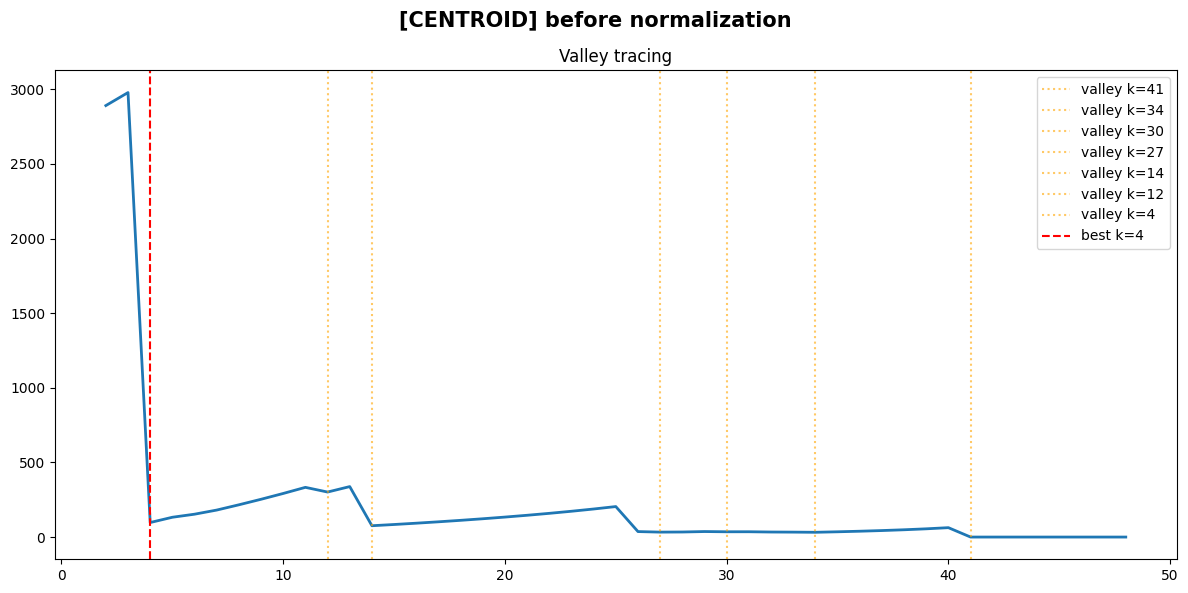

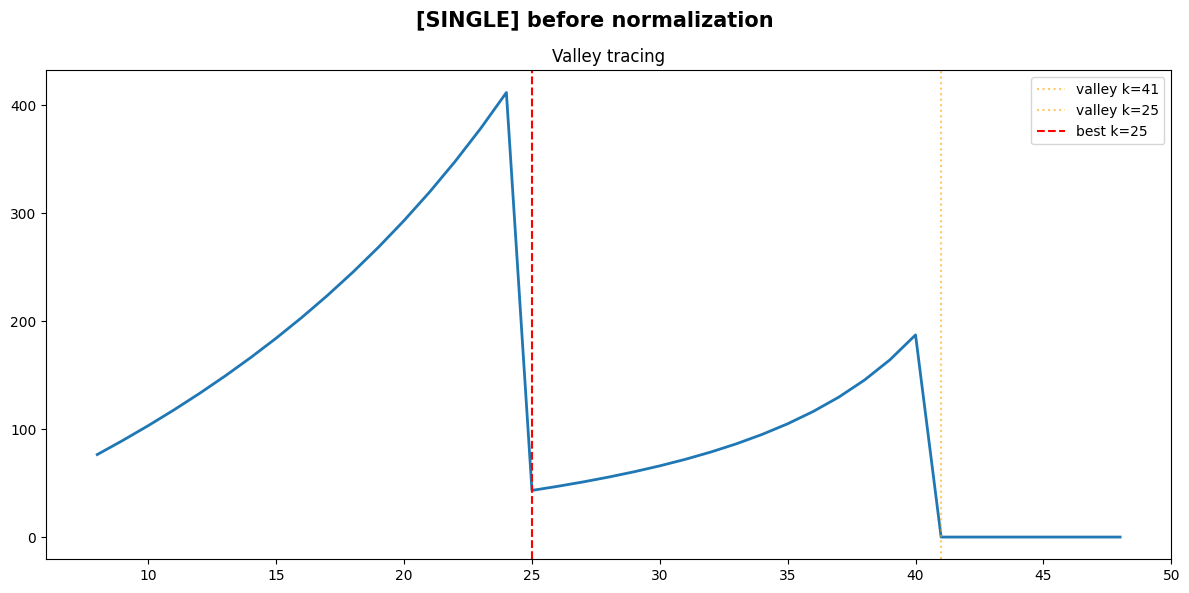

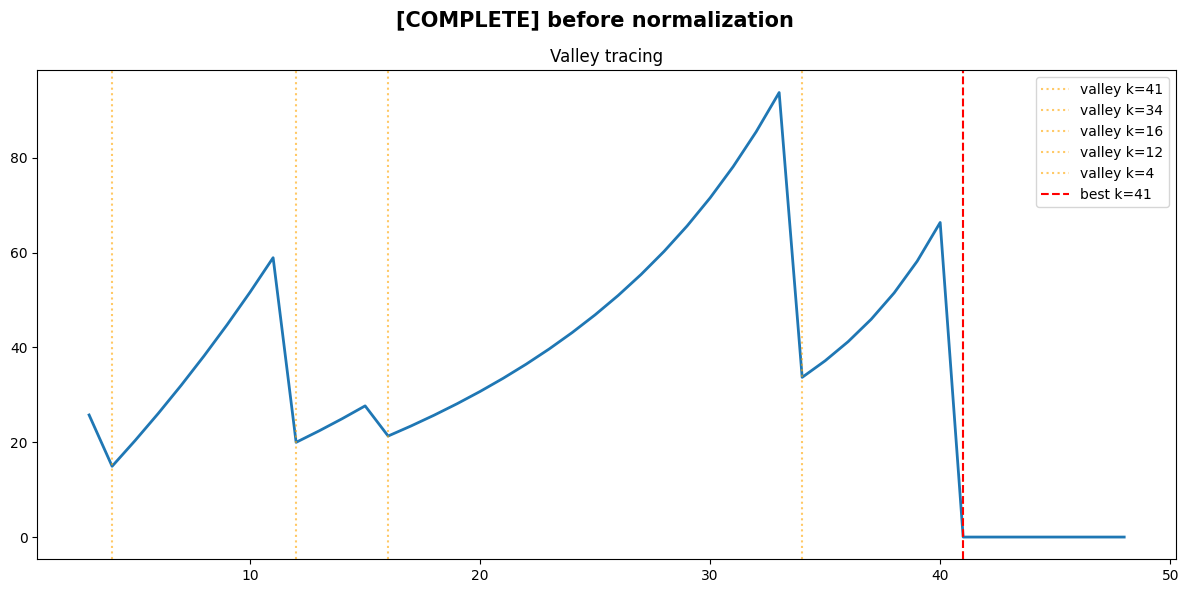

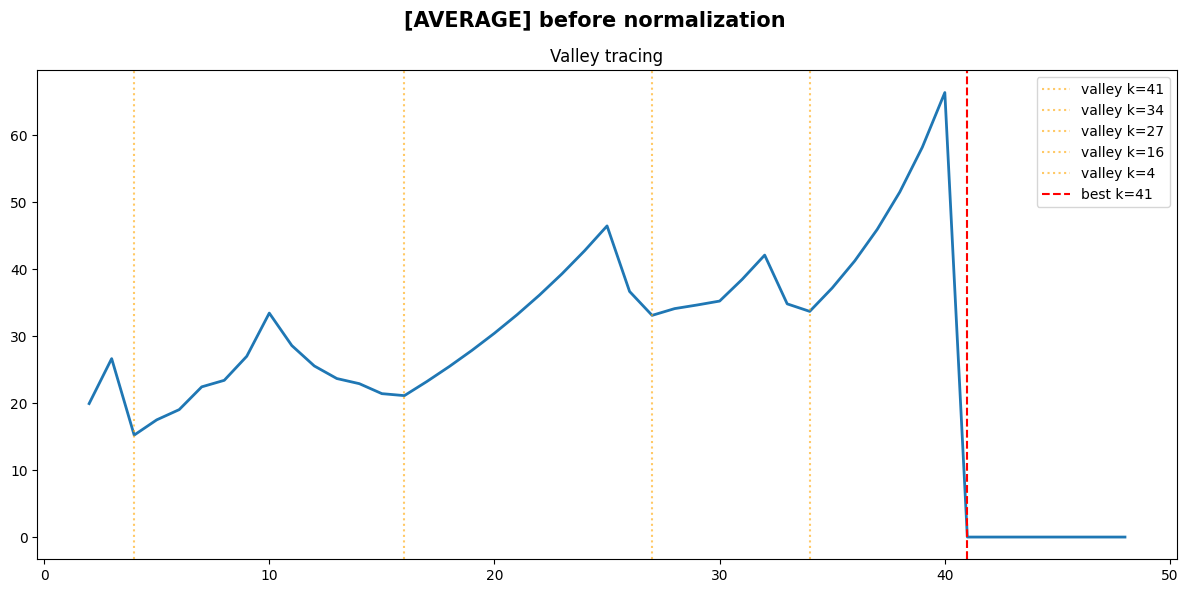

In [21]:
for ver_name, res in v_results.items():
    v_ratio = res['v_ratio']
    sil     = res['sil']
    k_list  = res['k_list']
    k_curv  = res['k_curv']
    k_sil   = res['k_sil']
    Z       = res['Z']
    vec     = res['vec']
    valley_k= res['valley_k']
    best_k  = res['best_k']

    fig, axes = plt.subplots(1, 1, figsize=(12, 6))
    fig.suptitle(ver_name, fontsize=15, fontweight='bold')

    axes.plot(k_list, v_ratio, linewidth=2, markersize=3)
    axes.set_title("Valley tracing")
    if valley_k:
        for vk in valley_k:
            axes.axvline(vk, color='orange', linestyle=':', alpha=0.6, label=f"valley k={vk}")
        axes.axvline(best_k, color='red', linestyle='--', label=f"best k={best_k}")
    axes.legend()

    plt.tight_layout()
    plt.show()

Other versions & sehnanigans